In [1]:
 !pip install folium openpyxl


   ---------------------------------------- 2/2 [folium]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

# Load restaurant data
restaurants = pd.read_csv(r"D:\Houston\Houston_All_Restaurants.csv")
print(f"Restaurants loaded: {len(restaurants)} rows")
print(f"Columns: {list(restaurants.columns)}")
print(restaurants.head(3))

# Load competitor data
competitors = pd.read_excel(r"D:\Houston\Houston_GTW_Competitors.xlsx", engine='openpyxl')
print(f"\nCompetitors loaded: {len(competitors)} rows")
print(competitors[['Site Name', 'Physical Type', 'Latitude', 'Longitude']].head(5))

Restaurants loaded: 4502 rows
Columns: ['name', 'address', 'addr:city', 'addr:postcode', 'cuisine', 'lat', 'lon', 'county']
            name                       address addr:city addr:postcode  \
0  Hartz Chicken                           NaN       NaN           NaN   
1         Subway  Northeast I-10 Frontage Road     Sealy       77474.0   
2   China Buffet                           NaN       NaN           NaN   

    cuisine        lat        lon  county  
0   chicken  29.765416 -96.152773  Austin  
1  sandwich  29.777136 -96.107493  Austin  
2   chinese  29.769773 -96.154332  Austin  

Competitors loaded: 22 rows
                                           Site Name Physical Type   Latitude  \
0  GENESYST INTERNATIONAL LIQUID WASTE PROCESSING...           5GG  29.708330   
1  LIQUID ENVIRONMENTAL SOLUTIONS OF TEXAS LP PRO...           5GG  29.785555   
2                          SOUTHWASTE HURST FACILITY           5GG  29.785800   
3                                DOWNSTREAM FACILI

In [7]:
# Clean competitor data - remove bad coordinates(Lat/Long==0.0)
competitors_clean = competitors[
    (competitors['Latitude'] > 29.0) & 
    (competitors['Latitude'] < 31.0) & 
    (competitors['Longitude'] < -94.0) & 
    (competitors['Longitude'] > -97.0)
].copy()

print(f"Competitors after cleaning: {len(competitors_clean)} (removed {len(competitors) - len(competitors_clean)} with bad coordinates)")

Competitors after cleaning: 17 (removed 5 with bad coordinates)


In [84]:
# Recreate county counts from current data
county_counts = restaurants.groupby('county').size().to_dict()
print("County counts:", county_counts)

import folium
from folium.plugins import HeatMap
import json
import urllib.request
# ... rest of your map code stays exactly the same

County counts: {'Austin': 13, 'Brazoria': 195, 'Chambers': 33, 'Fort Bend County': 372, 'Galveston': 122, 'Harris': 3417, 'Liberty': 38, 'Montgomery': 296, 'Waller': 16}


In [88]:
print("County counts:", county_counts)
print()
print("Testing Fort Bend lookup:", county_counts.get("Fort Bend", "NOT FOUND"))

County counts: {'Austin': 13, 'Brazoria': 195, 'Chambers': 33, 'Fort Bend County': 372, 'Galveston': 122, 'Harris': 3417, 'Liberty': 38, 'Montgomery': 296, 'Waller': 16}

Testing Fort Bend lookup: NOT FOUND


In [ ]:
#map 

In [90]:
import folium
from folium.plugins import HeatMap
import json
import urllib.request

# Create base map centered on Houston
houston_map = folium.Map(
    location=[29.76, -95.37],
    zoom_start=9,
    tiles='CartoDB positron'
)

# Download Texas county boundaries GeoJSON
url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
print("Downloading county boundaries...")
urllib.request.urlretrieve(url, "us_counties.json")

with open("us_counties.json", "r") as f:
    counties_geo = json.load(f)

# Houston MSA county FIPS codes
# Texas FIPS = 48, then county codes
houston_fips = {
    "48201": "Harris",
    "48157": "Fort Bend County", 
    "48339": "Montgomery",
    "48167": "Galveston",
    "48039": "Brazoria",
    "48071": "Chambers",
    "48291": "Liberty",
    "48473": "Waller",
    "48015": "Austin"
}

# Filter for only Houston MSA counties
houston_counties = {
    "type": "FeatureCollection",
    "features": [
        f for f in counties_geo["features"] 
        if f["id"] in houston_fips
    ]
}

print(f"Found {len(houston_counties['features'])} county boundaries")

# Add county boundaries to map
for feature in houston_counties["features"]:
    county_name = houston_fips.get(feature["id"], "Unknown")
    
    folium.GeoJson(
        feature,
        style_function=lambda x: {
            'fillColor': 'transparent',
            'color': '#FFD700',
            'weight': 3,
            'fillOpacity': 0
        },
        tooltip=county_name
    ).add_to(houston_map)
    
    # Add county label at center
    coords = feature["geometry"]["coordinates"]
    if feature["geometry"]["type"] == "Polygon":
        all_coords = coords[0]
    else:
        all_coords = coords[0][0]
    
    center_lat = sum(c[1] for c in all_coords) / len(all_coords)
    center_lon = sum(c[0] for c in all_coords) / len(all_coords)
    
    # Try multiple name formats to match
    rest_count = county_counts.get(county_name, 0)
    if rest_count == 0:
        rest_count = county_counts.get(county_name.replace(' ', '_') + '_County', 0)
    if rest_count == 0:
        rest_count = county_counts.get(county_name.replace(' ', '_'), 0)
    folium.Marker(
        location=[center_lat, center_lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:12px;font-weight:bold;color:white;text-shadow:2px 2px 4px black;">{county_name}<br>{rest_count} restaurants</div>'
        )
    ).add_to(houston_map)

# Add restaurant heat map
heat_data = restaurants[['lat', 'lon']].dropna().values.tolist()
HeatMap(
    heat_data, 
    radius=12,
    blur=15,
    max_zoom=13,
    name='Restaurant Density'
).add_to(houston_map)

# Add competitor markers
color_map = {'5GG': 'red', '5TL': 'orange', '5LV': 'blue'}

for _, row in competitors_clean.iterrows():
    facility_type = row['Physical Type']
    color = color_map.get(facility_type, 'gray')
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"<b>{row['Site Name']}</b><br>Type: {facility_type}<br>County: {row['County']}",
        icon=folium.Icon(color=color, icon='industry', prefix='fa'),
        tooltip=row['Site Name']
    ).add_to(houston_map)

# Add legend
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:12px;border-radius:5px;border:2px solid grey;font-size:12px;">
<b>Legend</b><br>
🔴 Grease Trap Processing (5GG)<br>
🟠 Liquid Waste Transfer (5TL)<br>
🔵 Liquid Waste (5LV)<br>
🟡 Restaurant Density (heat)<br>
━ County Boundaries
</div>
'''
houston_map.get_root().html.add_child(folium.Element(legend_html))

# Add layer control
folium.LayerControl().add_to(houston_map)

# Save
houston_map.save("Houston_Market_Map2.html")
print("Map saved with real county boundaries! Open Houston_Market_Map2.html in your browser.")

Found 9 county boundaries
Map saved with real county boundaries! Open Houston_Market_Map2.html in your browser.


In [27]:
import numpy as np
from math import radians, cos, sin, asin, sqrt

# Function to calculate distance in miles
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return round(3956 * c, 1)

# STEP 1: Create grid and count restaurants
grid_step = 0.02 #2km by 2km
restaurants_clean = restaurants.dropna(subset=['lat', 'lon'])

lat_min, lat_max = restaurants_clean['lat'].min(), restaurants_clean['lat'].max()
lon_min, lon_max = restaurants_clean['lon'].min(), restaurants_clean['lon'].max()

grid_cells = []
lat = lat_min
while lat <= lat_max:
    lon = lon_min
    while lon <= lon_max:
        count = len(restaurants_clean[
            (restaurants_clean['lat'] >= lat) & 
            (restaurants_clean['lat'] < lat + grid_step) &
            (restaurants_clean['lon'] >= lon) & 
            (restaurants_clean['lon'] < lon + grid_step)
        ])
        if count > 0:
            grid_cells.append({
                'center_lat': round(lat + grid_step/2, 4),
                'center_lon': round(lon + grid_step/2, 4),
                'restaurant_count': count
            })
        lon += grid_step
    lat += grid_step

grid_df = pd.DataFrame(grid_cells)
print(f"Total grid cells with restaurants: {len(grid_df)}")
print(f"Max restaurants in a cell: {grid_df['restaurant_count'].max()}")

# STEP 2: Find high density cells (top 15%)
threshold = grid_df['restaurant_count'].quantile(0.85)
high_density = grid_df[grid_df['restaurant_count'] >= threshold].copy()
print(f"Density threshold (top 15%): {threshold} restaurants per cell")
print(f"High-density cells: {len(high_density)}")

# STEP 3: Cluster into zones
zones = []
used = set()

for idx, cell in high_density.iterrows():
    if idx in used:
        continue
    cluster = high_density[
        (abs(high_density['center_lat'] - cell['center_lat']) <= 0.04) &
        (abs(high_density['center_lon'] - cell['center_lon']) <= 0.04)
    ]
    used.update(cluster.index)
    zones.append({
        'zone_lat': cluster['center_lat'].mean(),
        'zone_lon': cluster['center_lon'].mean(),
        'total_restaurants': cluster['restaurant_count'].sum(),
        'cells_in_zone': len(cluster)
    })

zones_df = pd.DataFrame(zones)
zones_df = zones_df.sort_values('total_restaurants', ascending=False).reset_index(drop=True)
print(f"High-density zones identified: {len(zones_df)}")

# STEP 4: Get 5GG facilities
gg_facilities = competitors_clean[competitors_clean['Physical Type'] == '5GG'].copy()
print(f"5GG facilities: {len(gg_facilities)}")

# STEP 5: Calculate distance AND identify zone names
results = []

for _, zone in zones_df.iterrows():
    # Calculate distances
    nearest_dist = 999
    nearest_name = ''
    distances_all = []
    
    for _, fac in gg_facilities.iterrows():
        dist = haversine(zone['zone_lat'], zone['zone_lon'],
                        fac['Latitude'], fac['Longitude'])
        distances_all.append(dist)
        if dist < nearest_dist:
            nearest_dist = dist
            nearest_name = fac['Site Name']
    
    within_10 = sum(1 for d in distances_all if d <= 10)
    within_20 = sum(1 for d in distances_all if d <= 20)
    
    # Identify zone name from restaurant data
    nearby = restaurants[
        (abs(restaurants['lat'] - zone['zone_lat']) < 0.03) &
        (abs(restaurants['lon'] - zone['zone_lon']) < 0.03)
    ]
    
    # Get city name
    city_name = 'Unknown'
    if 'addr:city' in nearby.columns:
        cities = nearby['addr:city'].dropna()
        if len(cities) > 0:
            city_name = cities.mode().iloc[0]
    
    # Get ZIP code
    zip_code = ''
    if 'addr:postcode' in nearby.columns:
        zips = nearby['addr:postcode'].dropna()
        if len(zips) > 0:
            try:
                zip_code = str(int(float(zips.mode().iloc[0])))
            except:
                zip_code = str(zips.mode().iloc[0])
    
    # Get county
    county_name = ''
    if 'county' in nearby.columns:
        counties = nearby['county'].dropna()
        if len(counties) > 0:
            county_name = counties.mode().iloc[0]
    
    # Get sample restaurant names
    sample = ', '.join(nearby['name'].dropna().head(3).tolist())
    
    # Gap assessment
    if nearest_dist > 15:
        gap = 'UNDERSERVED'
    elif nearest_dist > 10:
        gap = 'MODERATE GAP'
    elif nearest_dist > 5:
        gap = 'SLIGHT GAP'
    else:
        gap = 'SERVED'
    
    results.append({
        'Area/City': city_name,
        'County': county_name,
        'ZIP': zip_code,
        'Zone (lat, lon)': f"({round(zone['zone_lat'],2)}, {round(zone['zone_lon'],2)})",
        'Restaurants': int(zone['total_restaurants']),
        'Nearest 5GG Facility': nearest_name[:40],
        'Distance (miles)': nearest_dist,
        'Within 10mi': within_10,
        'Within 20mi': within_20,
        'Gap Assessment': gap,
        'Sample Restaurants': sample[:60]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Distance (miles)', ascending=False).reset_index(drop=True)

# Display
print("\n" + "=" * 130)
print("AUTOMATED GAP ANALYSIS: High-Density Restaurant Zones vs Nearest GTW Processing Facility")
print("=" * 130)
print()

for _, row in results_df.iterrows():
    print(f"  {row['Area/City']}, {row['County']} (ZIP: {row['ZIP']}) | {row['Zone (lat, lon)']}")
    print(f"    Restaurants: {row['Restaurants']} | Nearest: {row['Distance (miles)']}mi to {row['Nearest 5GG Facility']}")
    print(f"    Facilities within 10mi: {row['Within 10mi']} | within 20mi: {row['Within 20mi']} | {row['Gap Assessment']}")
    print(f"    Sample: {row['Sample Restaurants']}")
    print()

print("=" * 130)
print("\nSUMMARY:")
print(f"  Total high-density zones: {len(results_df)}")
print(f"  UNDERSERVED (>15 miles): {(results_df['Gap Assessment'] == 'UNDERSERVED').sum()}")
print(f"  MODERATE GAP (10-15 miles): {(results_df['Gap Assessment'] == 'MODERATE GAP').sum()}")
print(f"  SLIGHT GAP (5-10 miles): {(results_df['Gap Assessment'] == 'SLIGHT GAP').sum()}")
print(f"  SERVED (<5 miles): {(results_df['Gap Assessment'] == 'SERVED').sum()}")
print(f"\n  Restaurants in UNDERSERVED zones: {results_df[results_df['Gap Assessment'] == 'UNDERSERVED']['Restaurants'].sum()}")
print(f"  Restaurants in MODERATE GAP zones: {results_df[results_df['Gap Assessment'] == 'MODERATE GAP']['Restaurants'].sum()}")
print(f"  Average distance to nearest facility: {results_df['Distance (miles)'].mean():.1f} miles")

# Save
results_df.to_csv("Houston_Gap_Analysis_Complete.csv", index=False)
print("\nSaved to Houston_Gap_Analysis_Complete.csv")

Total grid cells with restaurants: 783
Max restaurants in a cell: 122
Density threshold (top 15%): 10.0 restaurants per cell
High-density cells: 120
High-density zones identified: 54
5GG facilities: 10

AUTOMATED GAP ANALYSIS: High-Density Restaurant Zones vs Nearest GTW Processing Facility

  Lake Jackson, Brazoria (ZIP: 77566) | (29.04, -95.46)
    Restaurants: 19 | Nearest: 47.2mi to DOWNSTREAM FACILITY
    Facilities within 10mi: 0 | within 20mi: 0 | UNDERSERVED
    Sample: Wursthaus Restaurant, La Casona, The Fill Station

  Galveston, Galveston (ZIP: 77550) | (29.3, -94.8)
    Restaurants: 13 | Nearest: 39.4mi to GENESYST INTERNATIONAL LIQUID WASTE PROC
    Facilities within 10mi: 0 | within 20mi: 0 | UNDERSERVED
    Sample: MOD Coffeehouse, Gumbo Bar, Miller's Seawall Restaurant

  Conroe, Montgomery (ZIP: 77304) | (30.3, -95.47)
    Restaurants: 24 | Nearest: 30.4mi to TAP INC DBA BIG K ENVIRONMENTAL
    Facilities within 10mi: 0 | within 20mi: 0 | UNDERSERVED
    Sample: Chipo

In [38]:
# Define Houston neighborhood lookup
def get_neighborhood(lat, lon):
    neighborhoods = [
        (29.76, -95.37, "Downtown / Midtown"),
        (29.75, -95.42, "Galleria / Uptown"),
        (29.74, -95.41, "Greenway / Upper Kirby"),
        (29.71, -95.53, "Chinatown / Bellaire"),
        (29.71, -95.41, "Westchase / Sharpstown"),
        (29.75, -95.47, "Memorial / Spring Branch"),
        (29.75, -95.51, "Energy Corridor West"),
        (29.75, -95.57, "Eldridge / West Houston"),
        (29.75, -95.60, "Barker Cypress / Far West"),
        (29.79, -95.38, "Heights / Northside"),
        (29.79, -95.42, "Garden Oaks / Oak Forest"),
        (29.79, -95.46, "Spring Branch North"),
        (29.81, -95.38, "Near Northside / Lindale"),
        (29.71, -95.32, "East Houston / Harrisburg"),
        (29.70, -95.44, "Sharpstown / Fondren"),
        (29.68, -95.12, "Pasadena / South Houston"),
        (29.64, -95.16, "South Belt / Ellington"),
        (29.89, -95.34, "Aldine / North Houston"),
        (29.90, -95.34, "Greenspoint / IAH Area"),
        (29.93, -95.42, "Jersey Village / NW Houston"),
        (29.96, -95.51, "Cypress / Fairfield"),
        (29.92, -95.58, "Cypress South"),
        (29.89, -95.66, "Katy / Mason Road"),
        (29.88, -95.66, "Katy / Cinco Ranch"),
        (29.78, -95.72, "Katy / Grand Pkwy West"),
        (29.78, -95.75, "Katy / Far West"),
        (29.98, -95.34, "Spring / Kuykendahl"),
        (29.98, -95.42, "Champions / FM 1960"),
        (30.00, -95.27, "Humble / Atascocita"),
        (30.00, -95.60, "Tomball / NW Harris"),
        (30.02, -95.17, "Kingwood / Lake Houston"),
        (29.55, -95.12, "League City / Clear Lake"),
        (29.55, -95.15, "Webster / NASA"),
        (29.56, -95.39, "Pearland / Friendswood"),
        (29.55, -95.76, "Rosenberg / Richmond"),
        (29.59, -95.60, "Sugar Land South"),
        (29.62, -95.64, "Sugar Land"),
        (29.82, -94.90, "Mont Belvieu / Baytown"),
    ]
    
    best_name = None
    best_dist = 999
    
    for n_lat, n_lon, name in neighborhoods:
        dist = ((lat - n_lat)**2 + (lon - n_lon)**2)**0.5
        if dist < best_dist:
            best_dist = dist
            best_name = name
    
    if best_dist < 0.04:
        return best_name
    return None

# Update Area/City column directly
for idx, row in results_df.iterrows():
    if row['Area/City'] == 'Houston' or row['Area/City'] == 'Unknown':
        coords = row['Zone (lat, lon)'].strip('()').split(',')
        z_lat = float(coords[0])
        z_lon = float(coords[1])
        neighborhood = get_neighborhood(z_lat, z_lon)
        if neighborhood:
            results_df.at[idx, 'Area/City'] = neighborhood

# Overwrite the same CSV
results_df.to_csv("Houston_Gap_Analysis_Complete.csv", index=False)

print("UPDATED - Houston zones now show neighborhood names:")
print("=" * 100)
for _, row in results_df.sort_values('Distance (miles)', ascending=False).iterrows():
    print(f"  {row['Area/City']:35s} | {row['County']:20s} | {row['Restaurants']} rest. | {row['Distance (miles)']}mi | {row['Gap Assessment']}")

UPDATED - Houston zones now show neighborhood names:
  Lake Jackson                        | Brazoria             | 19 rest. | 47.2mi | UNDERSERVED
  Galveston                           | Galveston            | 13 rest. | 39.4mi | UNDERSERVED
  Conroe                              | Montgomery           | 24 rest. | 30.4mi | UNDERSERVED
  Magnolia                            | Montgomery           | 22 rest. | 26.7mi | UNDERSERVED
  The Woodlands                       | Montgomery           | 83 rest. | 22.2mi | UNDERSERVED
  Baytown                             | Chambers             | 12 rest. | 21.1mi | UNDERSERVED
  Tomball                             | Harris               | 16 rest. | 20.6mi | UNDERSERVED
  Tomball                             | Harris               | 14 rest. | 19.8mi | UNDERSERVED
  Seabrook                            | Harris               | 12 rest. | 18.4mi | UNDERSERVED
  Spring                              | Harris               | 37 rest. | 17.0mi | UNDERSERV

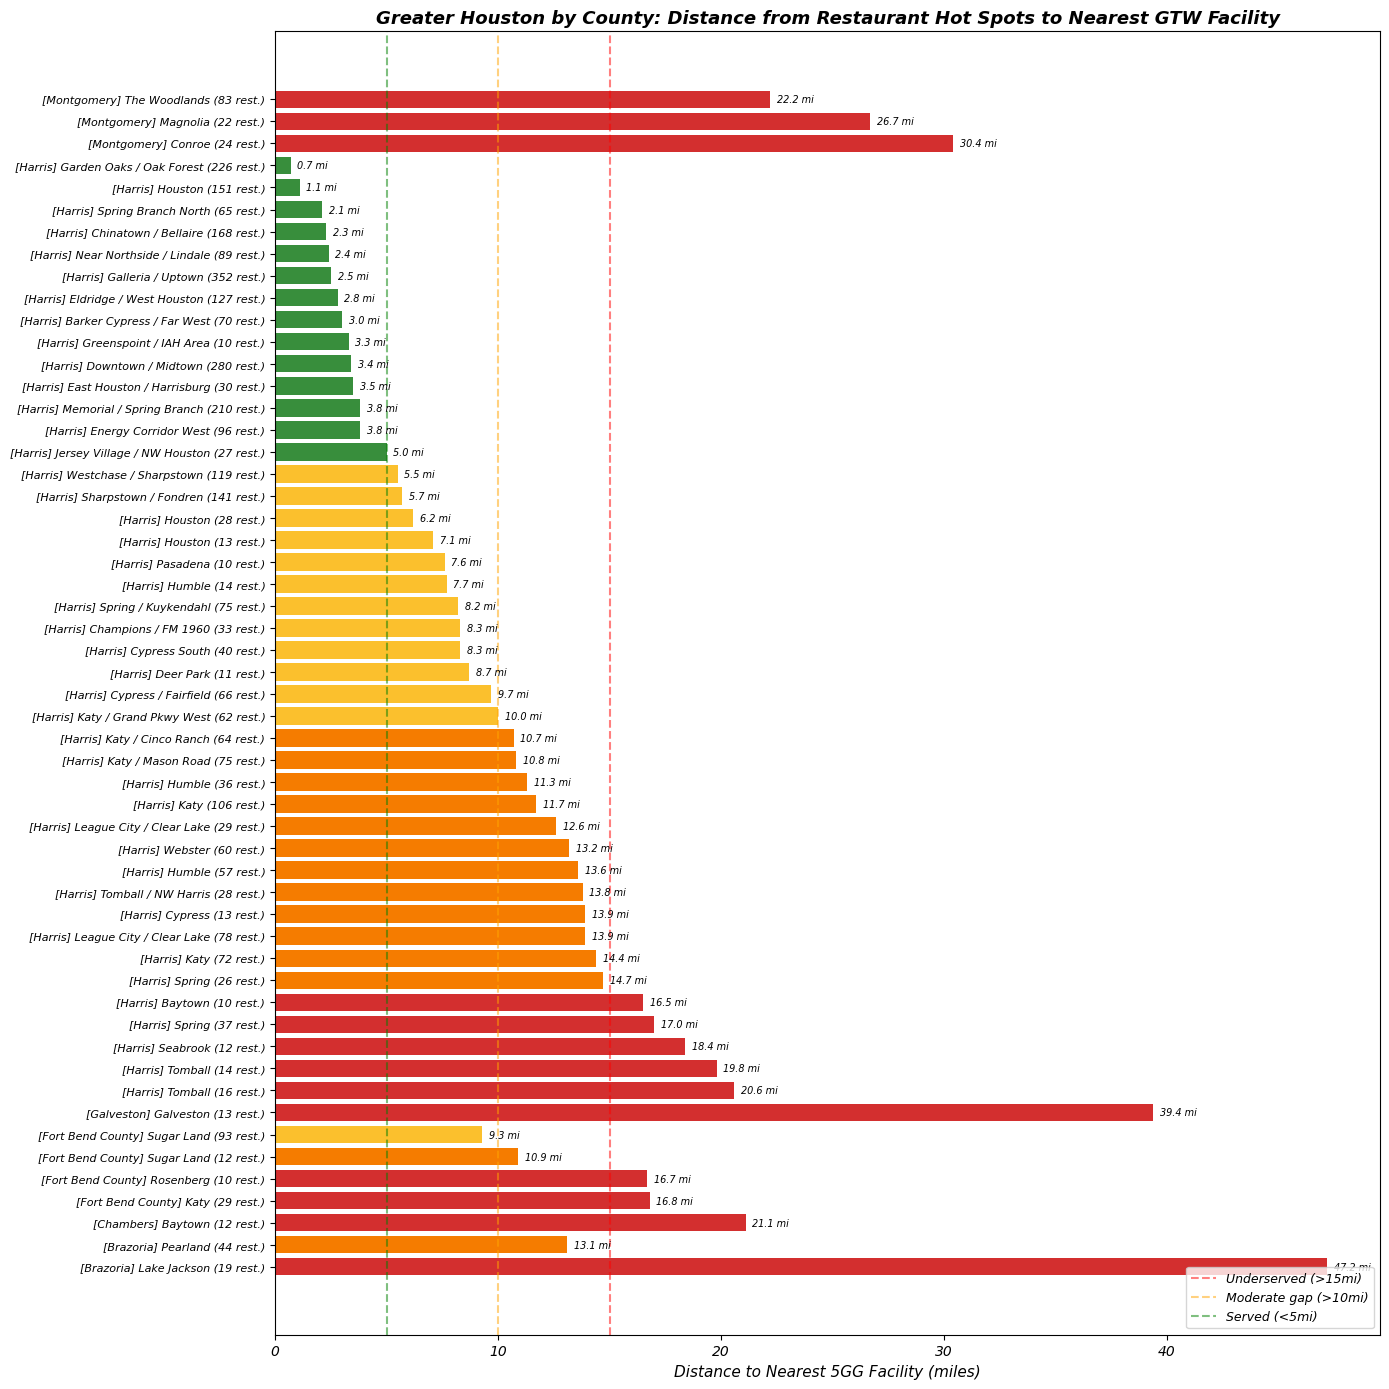

Chart 1 saved!


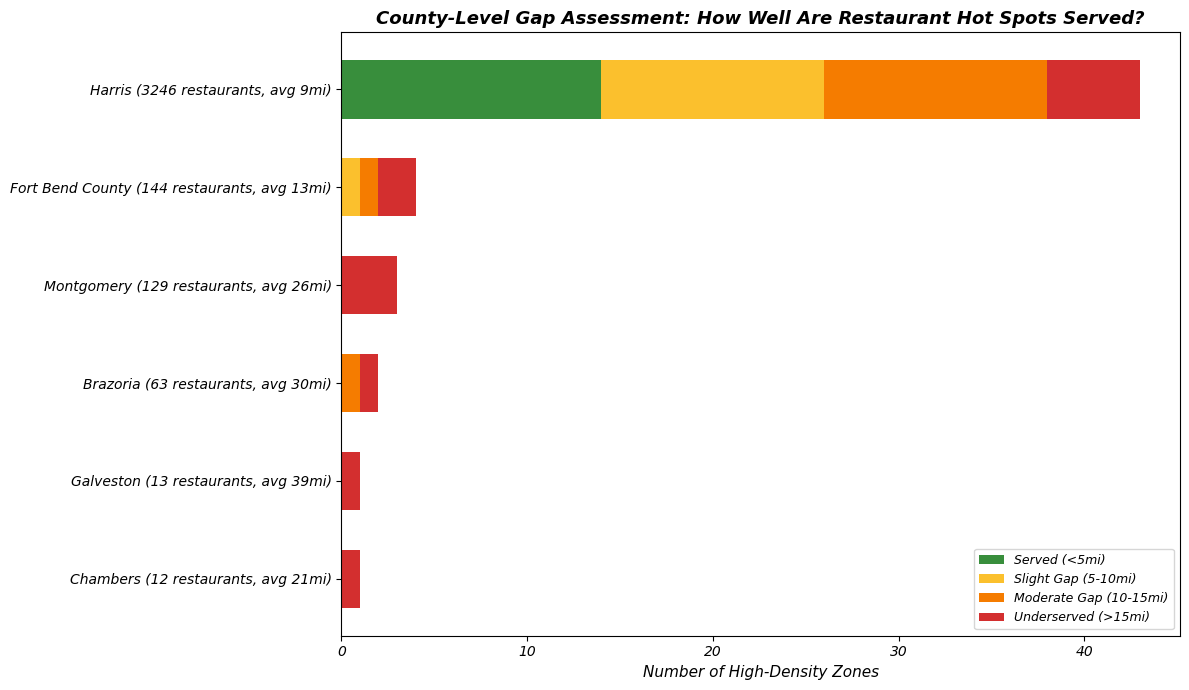

Chart 2 saved!


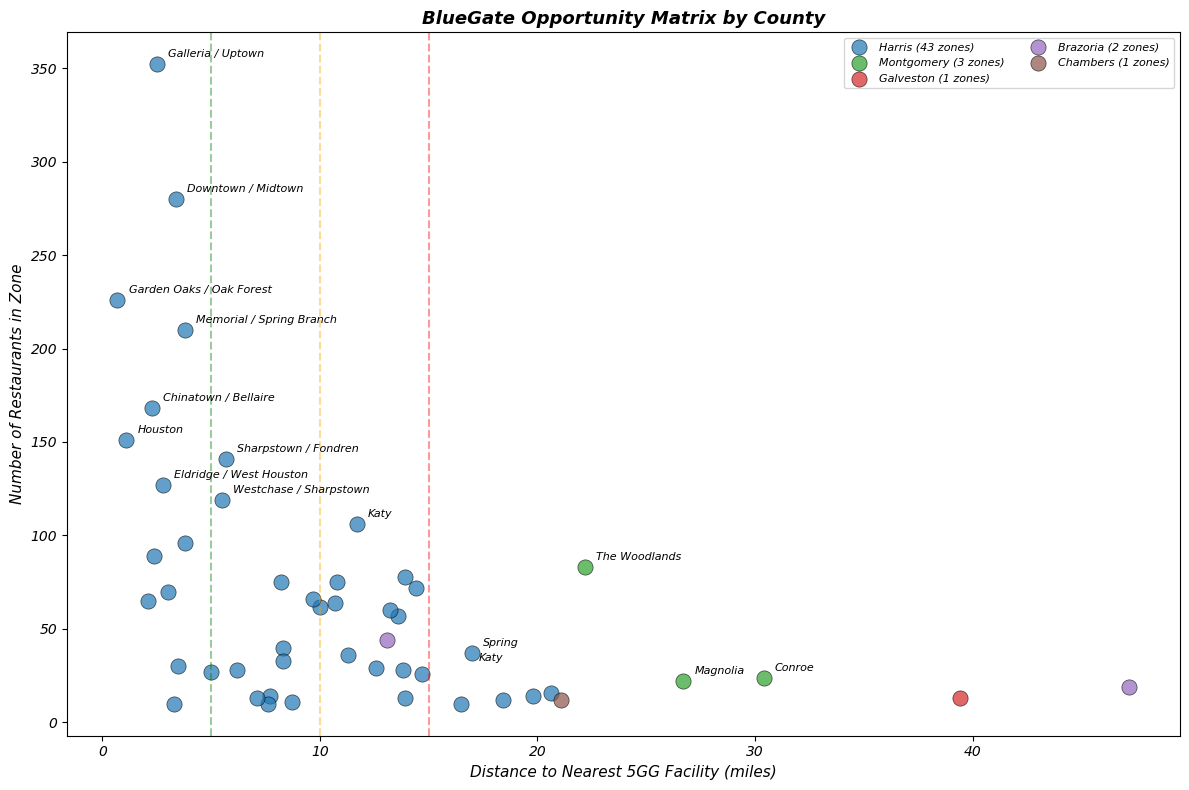

Chart 3 saved!

Files saved at:
C:\Users\Saloni Shahi\Documents\Chart1_Distance_By_County.png
C:\Users\Saloni Shahi\Documents\Chart2_County_Gap_Summary.png
C:\Users\Saloni Shahi\Documents\Chart3_Opportunity_By_County.png


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CHART 1: Grouped by county - Bar chart
# ============================================

fig, ax = plt.subplots(figsize=(14, 14))

# Sort by county first, then by distance
chart_data = results_df.sort_values(['County', 'Distance (miles)'], ascending=[True, False])

# Color based on gap assessment
colors = []
for gap in chart_data['Gap Assessment']:
    if gap == 'UNDERSERVED':
        colors.append('#d32f2f')
    elif gap == 'MODERATE GAP':
        colors.append('#f57c00')
    elif gap == 'SLIGHT GAP':
        colors.append('#fbc02d')
    else:
        colors.append('#388e3c')

# Create labels with county + area + restaurant count
labels = [f"[{row['County']}] {row['Area/City']} ({row['Restaurants']} rest.)" 
          for _, row in chart_data.iterrows()]

bars = ax.barh(range(len(chart_data)), chart_data['Distance (miles)'].values, color=colors)

ax.set_yticks(range(len(chart_data)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Distance to Nearest 5GG Facility (miles)', fontsize=11)
ax.set_title('Greater Houston by County: Distance from Restaurant Hot Spots to Nearest GTW Facility', 
             fontsize=13, fontweight='bold')

# Add distance labels on bars
for i, (bar, dist) in enumerate(zip(bars, chart_data['Distance (miles)'].values)):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{dist} mi', va='center', fontsize=7)

# Add threshold lines
ax.axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Underserved (>15mi)')
ax.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='Moderate gap (>10mi)')
ax.axvline(x=5, color='green', linestyle='--', alpha=0.5, label='Served (<5mi)')

ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('Chart1_Distance_By_County.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")


# ============================================
# CHART 2: County summary - stacked bar showing gap breakdown
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))

# Aggregate by county
county_summary = results_df.groupby('County').agg(
    Total_Restaurants=('Restaurants', 'sum'),
    Total_Zones=('Restaurants', 'count'),
    Avg_Distance=('Distance (miles)', 'mean'),
    Underserved=('Gap Assessment', lambda x: (x == 'UNDERSERVED').sum()),
    Moderate_Gap=('Gap Assessment', lambda x: (x == 'MODERATE GAP').sum()),
    Slight_Gap=('Gap Assessment', lambda x: (x == 'SLIGHT GAP').sum()),
    Served=('Gap Assessment', lambda x: (x == 'SERVED').sum())
).reset_index()

county_summary = county_summary.sort_values('Total_Restaurants', ascending=True)

# Stacked horizontal bar chart
y_pos = range(len(county_summary))
bar_height = 0.6

served = ax.barh(y_pos, county_summary['Served'], bar_height, color='#388e3c', label='Served (<5mi)')
slight = ax.barh(y_pos, county_summary['Slight_Gap'], bar_height, 
                 left=county_summary['Served'], color='#fbc02d', label='Slight Gap (5-10mi)')
moderate = ax.barh(y_pos, county_summary['Moderate_Gap'], bar_height,
                   left=county_summary['Served'] + county_summary['Slight_Gap'], 
                   color='#f57c00', label='Moderate Gap (10-15mi)')
underserved = ax.barh(y_pos, county_summary['Underserved'], bar_height,
                      left=county_summary['Served'] + county_summary['Slight_Gap'] + county_summary['Moderate_Gap'],
                      color='#d32f2f', label='Underserved (>15mi)')

# Labels
labels = [f"{row['County']} ({row['Total_Restaurants']} restaurants, avg {row['Avg_Distance']:.0f}mi)" 
          for _, row in county_summary.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of High-Density Zones', fontsize=11)
ax.set_title('County-Level Gap Assessment: How Well Are Restaurant Hot Spots Served?', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('Chart2_County_Gap_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")


# ============================================
# CHART 3: Scatter plot grouped by county color
# ============================================

fig, ax = plt.subplots(figsize=(12, 8))

county_colors = {
    'Harris': '#1f77b4',
    'Fort_Bend_County': '#ff7f0e',
    'Montgomery': '#2ca02c',
    'Galveston': '#d62728',
    'Brazoria': '#9467bd',
    'Chambers': '#8c564b',
    'Liberty': '#e377c2',
    'Waller': '#7f7f7f',
    'Austin': '#bcbd22'
}

for county, color in county_colors.items():
    subset = results_df[results_df['County'] == county]
    if len(subset) > 0:
        ax.scatter(subset['Distance (miles)'], subset['Restaurants'],
                  c=color, s=120, label=f"{county} ({len(subset)} zones)", 
                  alpha=0.7, edgecolors='black', linewidth=0.5)

# Label important zones
for _, row in results_df.iterrows():
    if row['Distance (miles)'] > 15 and row['Restaurants'] > 20:
        ax.annotate(f"{row['Area/City']}", 
                   (row['Distance (miles)'], row['Restaurants']),
                   textcoords="offset points", xytext=(8, 5), fontsize=8)
    elif row['Restaurants'] > 100:
        ax.annotate(f"{row['Area/City']}", 
                   (row['Distance (miles)'], row['Restaurants']),
                   textcoords="offset points", xytext=(8, 5), fontsize=8)

# Threshold lines
ax.axvline(x=15, color='red', linestyle='--', alpha=0.4)
ax.axvline(x=10, color='orange', linestyle='--', alpha=0.4)
ax.axvline(x=5, color='green', linestyle='--', alpha=0.4)

ax.set_xlabel('Distance to Nearest 5GG Facility (miles)', fontsize=11)
ax.set_ylabel('Number of Restaurants in Zone', fontsize=11)
ax.set_title('FOG Disposal Opportunity Matrix by County', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('Chart3_Opportunity_By_County.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# Print file locations
import os
print("\nFiles saved at:")
print(os.path.abspath('Chart1_Distance_By_County.png'))
print(os.path.abspath('Chart2_County_Gap_Summary.png'))
print(os.path.abspath('Chart3_Opportunity_By_County.png'))

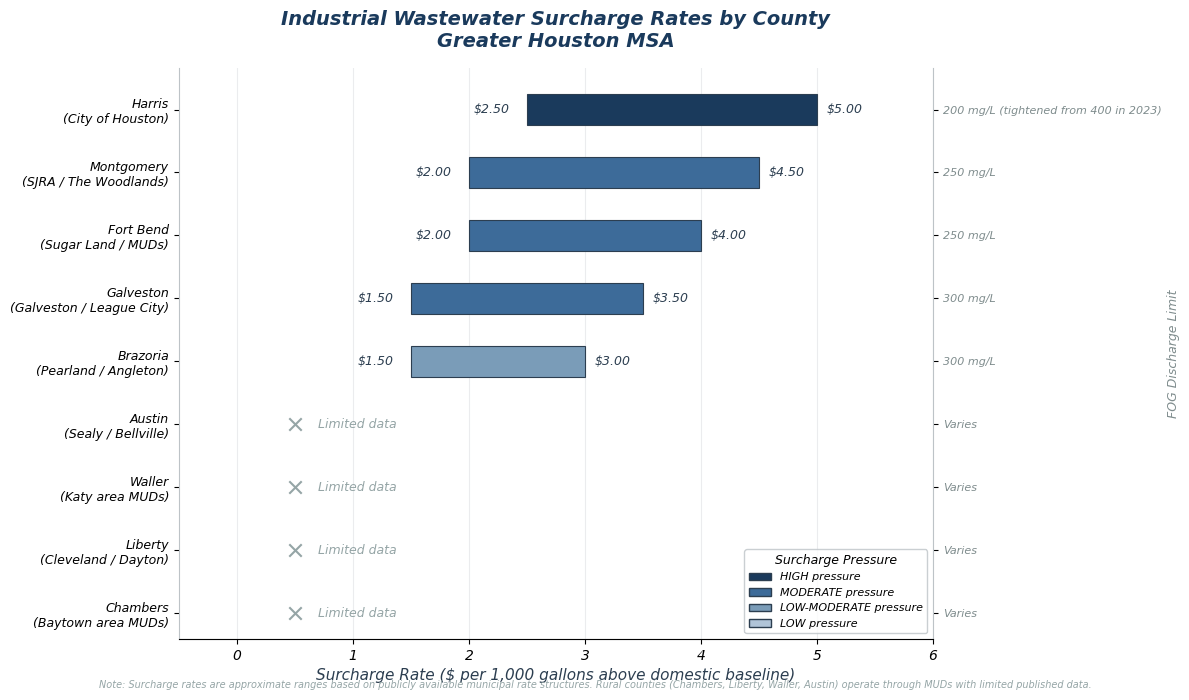

Saved to: C:\Users\Saloni Shahi\Documents\Chart_Surcharge_Rates.png


In [52]:
import matplotlib.pyplot as plt

# Read surcharge data from file
surcharge = pd.read_excel(r"D:\Houston\Surcharge_county.xlsx", engine='openpyxl')

# Extract min and max rates from the range column
rate_col = 'Approximate Rate (per 1,000 gal above domestic baseline)'

min_rates = []
max_rates = []
has_data = []

for rate in surcharge[rate_col]:
    rate_str = str(rate).replace('$', '').replace(',', '').strip()
    if 'Limited' in rate_str or rate_str == 'nan':
        min_rates.append(0)
        max_rates.append(0)
        has_data.append(False)
    else:
        parts = rate_str.split('-')
        min_rates.append(float(parts[0].strip()))
        max_rates.append(float(parts[1].strip()))
        has_data.append(True)

surcharge['Min_Rate'] = min_rates
surcharge['Max_Rate'] = max_rates
surcharge['Has_Data'] = has_data

# Sort by max rate descending
surcharge = surcharge.sort_values('Max_Rate', ascending=True).reset_index(drop=True)

# ============================================
# CHART: Horizontal range bar - Surcharge rates by county
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))


colors_with_data = {
    'HIGH': '#1a3a5c',         # Dark navy
    'MODERATE': '#3d6b99',     # Medium blue
    'LOW-MODERATE': '#7a9cb8', # Light steel blue
    'LOW': '#b0c4d8'           # Light grey-blue
}

bar_height = 0.5

for i, (_, row) in enumerate(surcharge.iterrows()):
    pressure = row['Surcharge Pressure']
    color = colors_with_data.get(pressure, '#b0c4d8')
    
    if row['Has_Data']:
        # Draw range bar from min to max
        ax.barh(i, row['Max_Rate'] - row['Min_Rate'], bar_height, 
                left=row['Min_Rate'], color=color, edgecolor='#2c3e50', linewidth=0.8)
        
        # Add min and max labels
        ax.text(row['Min_Rate'] - 0.15, i, f"${row['Min_Rate']:.2f}", 
                va='center', ha='right', fontsize=9, color='#2c3e50')
        ax.text(row['Max_Rate'] + 0.08, i, f"${row['Max_Rate']:.2f}", 
                va='center', ha='left', fontsize=9, color='#2c3e50')
    else:
        # Draw a small marker for "Limited data"
        ax.scatter(0.5, i, marker='x', color='#95a5a6', s=80, zorder=5)
        ax.text(0.7, i, "Limited data", va='center', ha='left', 
                fontsize=9, color='#95a5a6', fontstyle='italic')

# Y-axis labels with county + utility name
labels = [f"{row['County']}\n({row['Major City/Utility']})" for _, row in surcharge.iterrows()]
ax.set_yticks(range(len(surcharge)))
ax.set_yticklabels(labels, fontsize=9)

# Formatting
ax.set_xlabel('Surcharge Rate ($ per 1,000 gallons above domestic baseline)', fontsize=11, color='#2c3e50')
ax.set_title('Industrial Wastewater Surcharge Rates by County\nGreater Houston MSA', 
             fontsize=14, fontweight='bold', color='#1a3a5c', pad=15)
ax.set_xlim(-0.5, 6)
ax.grid(axis='x', alpha=0.3, color='#bdc3c7')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Add FOG limit annotations on the right side
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(range(len(surcharge)))
fog_labels = [str(row['FOG Discharge Limit']) for _, row in surcharge.iterrows()]
ax2.set_yticklabels(fog_labels, fontsize=8, color='#7f8c8d')
ax2.set_ylabel('FOG Discharge Limit', fontsize=9, color='#7f8c8d')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_color('#bdc3c7')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a3a5c', edgecolor='#2c3e50', label='HIGH pressure'),
    Patch(facecolor='#3d6b99', edgecolor='#2c3e50', label='MODERATE pressure'),
    Patch(facecolor='#7a9cb8', edgecolor='#2c3e50', label='LOW-MODERATE pressure'),
    Patch(facecolor='#b0c4d8', edgecolor='#2c3e50', label='LOW pressure'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, 
          title='Surcharge Pressure', title_fontsize=9,
          facecolor='white', edgecolor='#bdc3c7')

# Add note at bottom
fig.text(0.5, 0.01, 
         'Note: Surcharge rates are approximate ranges based on publicly available municipal rate structures. '
         'Rural counties (Chambers, Liberty, Waller, Austin) operate through MUDs with limited published data.',
         ha='center', fontsize=7, color='#95a5a6', fontstyle='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('Chart_Surcharge_Rates.png', dpi=150, bbox_inches='tight')
plt.show()

import os
print(f"Saved to: {os.path.abspath('Chart_Surcharge_Rates.png')}")

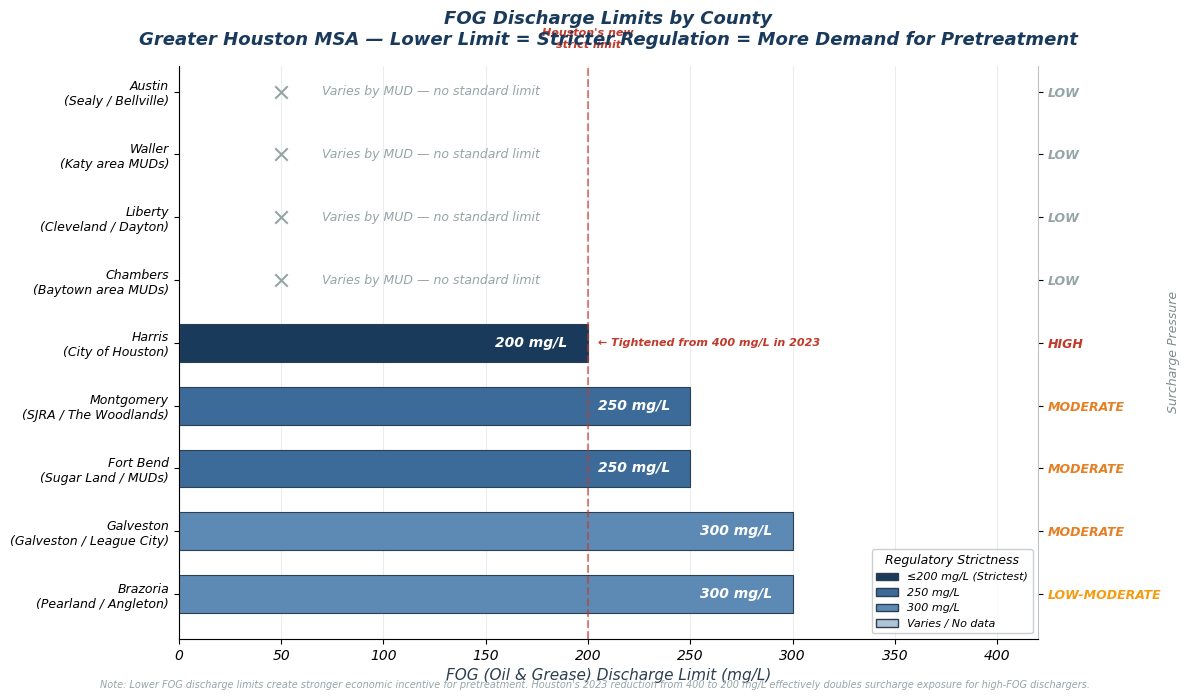

Saved to: C:\Users\Saloni Shahi\Documents\Chart_FOG_Limits.png


In [56]:
# ============================================
# CHART: FOG Discharge Limits by County
# ============================================

fig, ax = plt.subplots(figsize=(12, 7))

# Extract FOG limits as numbers
fog_limits = []
fog_labels_list = []
fog_has_data = []

for _, row in surcharge.iterrows():
    fog_str = str(row['FOG Discharge Limit'])
    if 'Varies' in fog_str or fog_str == 'nan':
        fog_limits.append(0)
        fog_has_data.append(False)
        fog_labels_list.append('Varies by MUD')
    else:
        # Extract the number (e.g., "200 mg/L" or "200 mg/L (tightened from 400 in 2023)")
        num = int(''.join(filter(str.isdigit, fog_str.split('mg')[0])))
        fog_limits.append(num)
        fog_has_data.append(True)
        fog_labels_list.append(fog_str)

surcharge['FOG_Limit_Num'] = fog_limits
surcharge['FOG_Has_Data'] = fog_has_data

# Sort by FOG limit ascending (strictest first)
fog_chart = surcharge.sort_values('FOG_Limit_Num', ascending=False).reset_index(drop=True)

# Color gradient - stricter limits get darker color (more regulatory pressure)
def get_fog_color(limit, has_data):
    if not has_data:
        return '#b0c4d8'      # Light grey-blue for no data
    elif limit <= 200:
        return '#1a3a5c'      # Darkest navy - strictest
    elif limit <= 250:
        return '#3d6b99'      # Medium blue
    elif limit <= 300:
        return '#5d8ab4'      # Medium-light blue
    else:
        return '#7a9cb8'      # Light steel blue

bar_height = 0.6

for i, (_, row) in enumerate(fog_chart.iterrows()):
    color = get_fog_color(row['FOG_Limit_Num'], row['FOG_Has_Data'])
    
    if row['FOG_Has_Data']:
        bar = ax.barh(i, row['FOG_Limit_Num'], bar_height, color=color, 
                       edgecolor='#2c3e50', linewidth=0.8)
        
        # Add limit value on the bar
        ax.text(row['FOG_Limit_Num'] - 10, i, f"{row['FOG_Limit_Num']} mg/L", 
                va='center', ha='right', fontsize=10, color='white', fontweight='bold')
        
        # Add note for Houston's tightening
        if 'tightened' in str(row['FOG Discharge Limit']).lower():
            ax.annotate('← Tightened from 400 mg/L in 2023', 
                       xy=(row['FOG_Limit_Num'] + 5, i),
                       fontsize=8, color='#c0392b', fontweight='bold',
                       va='center')
    else:
        ax.scatter(50, i, marker='x', color='#95a5a6', s=80, zorder=5)
        ax.text(70, i, "Varies by MUD — no standard limit", 
                va='center', ha='left', fontsize=9, color='#95a5a6', fontstyle='italic')

# Y-axis labels
labels = [f"{row['County']}\n({row['Major City/Utility']})" for _, row in fog_chart.iterrows()]
ax.set_yticks(range(len(fog_chart)))
ax.set_yticklabels(labels, fontsize=9)

# Add a reference line at 200 mg/L (Houston's new strict limit)
ax.axvline(x=200, color='#c0392b', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(200, len(fog_chart) - 0.3, 'Houston\'s new\nstrict limit', 
        fontsize=8, color='#c0392b', ha='center', fontweight='bold')

# Formatting
ax.set_xlabel('FOG (Oil & Grease) Discharge Limit (mg/L)', fontsize=11, color='#2c3e50')
ax.set_title('FOG Discharge Limits by County\nGreater Houston MSA — Lower Limit = Stricter Regulation = More Demand for Pretreatment', 
             fontsize=13, fontweight='bold', color='#1a3a5c', pad=15)
ax.set_xlim(0, 420)
ax.grid(axis='x', alpha=0.3, color='#bdc3c7')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Add surcharge pressure on the right
# Add surcharge pressure labels on the right
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(range(len(fog_chart)))

pressure_colors = {
    'HIGH': '#c0392b',
    'MODERATE': '#e67e22',
    'LOW-MODERATE': '#f39c12',
    'LOW': '#95a5a6'
}

pressure_labels_styled = []
for _, row in fog_chart.iterrows():
    pressure_labels_styled.append(row['Surcharge Pressure'])

ax2.set_yticklabels(pressure_labels_styled, fontsize=9, fontweight='bold')

# Color each label individually
for i, label in enumerate(ax2.get_yticklabels()):
    pressure = fog_chart.iloc[i]['Surcharge Pressure']
    label.set_color(pressure_colors.get(pressure, '#95a5a6'))

ax2.set_ylabel('Surcharge Pressure', fontsize=9, color='#7f8c8d')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color('#bdc3c7')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a3a5c', edgecolor='#2c3e50', label='≤200 mg/L (Strictest)'),
    Patch(facecolor='#3d6b99', edgecolor='#2c3e50', label='250 mg/L'),
    Patch(facecolor='#5d8ab4', edgecolor='#2c3e50', label='300 mg/L'),
    Patch(facecolor='#b0c4d8', edgecolor='#2c3e50', label='Varies / No data'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Regulatory Strictness', title_fontsize=9,
          facecolor='white', edgecolor='#bdc3c7')

# Bottom note
fig.text(0.5, 0.01,
         'Note: Lower FOG discharge limits create stronger economic incentive for pretreatment. '
         'Houston\'s 2023 reduction from 400 to 200 mg/L effectively doubles surcharge exposure for high-FOG dischargers.',
         ha='center', fontsize=7, color='#95a5a6', fontstyle='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('Chart_FOG_Limits.png', dpi=150, bbox_inches='tight')
plt.show()

import os
print(f"Saved to: {os.path.abspath('Chart_FOG_Limits.png')}")

In [64]:
!pip install squarify


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


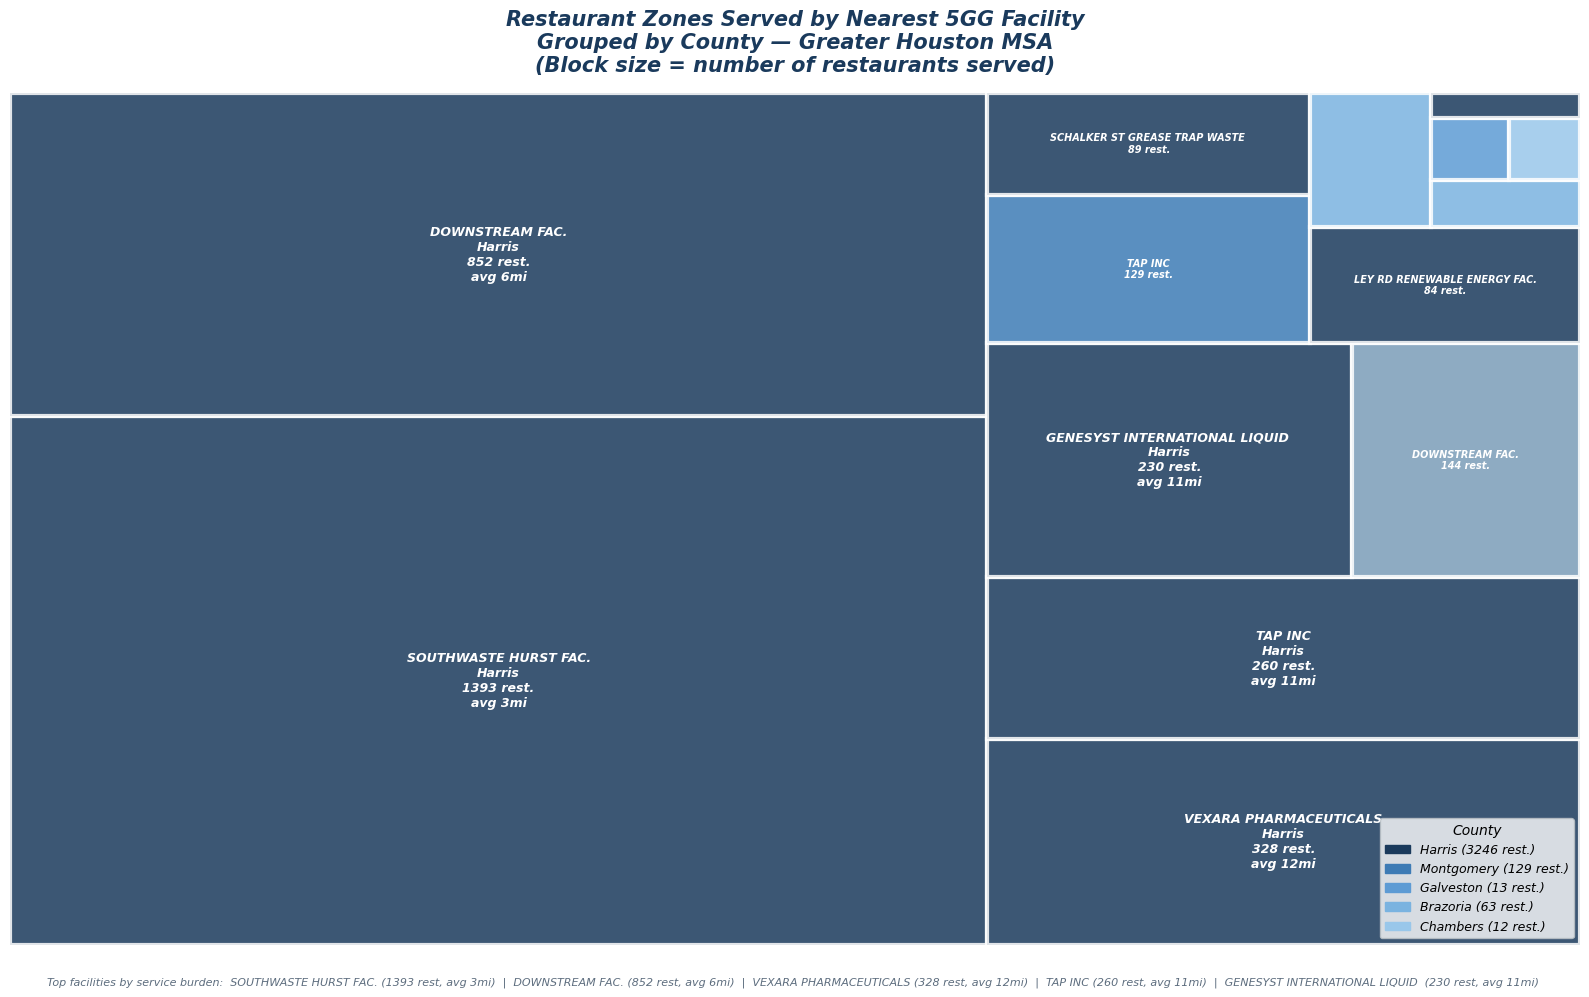

Saved to: C:\Users\Saloni Shahi\Documents\Chart_Treemap_Facility_Coverage.png


In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import squarify

# Build treemap data (reuse facility_served from previous code)
facility_served_sorted = facility_served.sort_values('Restaurants_Served', ascending=False).reset_index(drop=True)

county_colors = {
    'Harris': '#1a3a5c',
    'Fort_Bend_County': '#2c5f8a',
    'Montgomery': '#3d7bb5',
    'Galveston': '#5d9bd4',
    'Brazoria': '#7ab3e0',
    'Chambers': '#99c7ea',
}

sizes = facility_served_sorted['Restaurants_Served'].tolist()
colors = [county_colors.get(row['County'], '#7a9cb8') for _, row in facility_served_sorted.iterrows()]

fig, ax = plt.subplots(figsize=(16, 10))

# Draw treemap WITHOUT labels first
squarify.plot(
    sizes=sizes,
    color=colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=3,
    ax=ax
)

# Now add labels manually — only on blocks big enough
# Get the rectangles squarify calculated
normed = squarify.normalize_sizes(sizes, 100, 100)
rects = squarify.squarify(normed, 0, 0, 100, 100)

for i, (rect, (_, row)) in enumerate(zip(rects, facility_served_sorted.iterrows())):
    x = rect['x'] + rect['dx'] / 2
    y = rect['y'] + rect['dy'] / 2
    w = rect['dx']
    h = rect['dy']
    
    facility = row['Facility_Short']
    county = row['County'].replace('_', ' ')
    rest_count = row['Restaurants_Served']
    avg_dist = row['Avg_Distance']
    
    # Scale coordinates to figure
    x_fig = x / 100
    y_fig = y / 100
    
    if rest_count >= 200:
        # Big blocks — full label inside
        ax.text(x_fig * ax.get_xlim()[1], y_fig * ax.get_ylim()[1],
                f"{facility}\n{county}\n{rest_count} rest.\navg {avg_dist:.0f}mi",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white',
                transform=ax.transData)
    elif rest_count >= 50:
        # Medium blocks — short label
        ax.text(x_fig * ax.get_xlim()[1], y_fig * ax.get_ylim()[1],
                f"{facility}\n{rest_count} rest.",
                ha='center', va='center', fontsize=7, fontweight='bold', color='white',
                transform=ax.transData)
    # Small blocks — no label (too crowded)

ax.set_title('Restaurant Zones Served by Nearest 5GG Facility\nGrouped by County — Greater Houston MSA\n(Block size = number of restaurants served)',
             fontsize=15, fontweight='bold', color='#1a3a5c', pad=15)
ax.axis('off')

# Add legend
legend_patches = []
for county, color in county_colors.items():
    county_total = facility_served[facility_served['County'] == county]['Restaurants_Served'].sum()
    if county_total > 0:
        display_name = county.replace('_', ' ')
        legend_patches.append(mpatches.Patch(color=color, label=f'{display_name} ({county_total} rest.)'))

ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='County', title_fontsize=10,
          facecolor='white', edgecolor='#bdc3c7')

# Add summary table below
summary_text = "Top facilities by service burden:  "
for _, row in facility_served_sorted.head(5).iterrows():
    summary_text += f"{row['Facility_Short']} ({row['Restaurants_Served']} rest, avg {row['Avg_Distance']:.0f}mi)  |  "

fig.text(0.5, 0.01, summary_text[:-4],
         ha='center', fontsize=8, color='#5d6d7e', fontstyle='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)
plt.savefig('Chart_Treemap_Facility_Coverage.png', dpi=150, bbox_inches='tight')
plt.show()

import os
print(f"Saved to: {os.path.abspath('Chart_Treemap_Facility_Coverage.png')}")